In [2]:
# Setup: imports, paths, EPW data, and simulation helper
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

BASE = Path.home() / "Desktop/mold_risk_model"
EPW_DIR = BASE / "data/raw/epw"
FIG_DIR = BASE / "figures"
FIG_DIR.mkdir(exist_ok=True)

MONTH_STARTS = [0, 744, 1416, 2160, 2880, 3624, 4344, 5088, 5832, 6552, 7296, 8016]
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

CITY_COLORS = {
    "USA_CA_Port.Chicago.": "#2a9d8f",
    "USA_FL_Miami.Intl.AP": "#e63946",
    "USA_LA_New.Orleans-N": "#f4a261",
    "USA_TX_Houston-Bush.": "#457b9d",
}
CITY_LABELS = {
    "USA_CA_Port.Chicago.": "Port Chicago, CA (dry baseline)",
    "USA_FL_Miami.Intl.AP": "Miami, FL",
    "USA_LA_New.Orleans-N": "New Orleans, LA",
    "USA_TX_Houston-Bush.": "Houston, TX",
}

# Load algorithm function (fallback to local definition if missing)
ALGO_DIR = BASE / "notebooks"
if str(ALGO_DIR) not in sys.path:
    sys.path.append(str(ALGO_DIR))

try:
    from hygro_algo import compute_moisture_index
except Exception as exc:
    print("Could not import hygro_algo; using local definitions:", exc)

    def rh_crit(temp_c):
        temp_c = np.asarray(temp_c, dtype=float)
        return np.where(temp_c < 0, 1.0,
               np.where(temp_c < 5, 0.95,
               np.where(temp_c < 10, 0.90,
               np.where(temp_c < 15, 0.85,
               np.where(temp_c < 20, 0.80,
               np.where(temp_c < 25, 0.75, 0.70))))))

    def e_sat(t):
        return 6.1078 * np.exp(17.27 * t / (t + 237.3))

    def surface_rh(surface_temp_c, outdoor_temp_c, outdoor_rh_pct):
        e_out = (outdoor_rh_pct / 100.0) * e_sat(outdoor_temp_c)
        return np.clip(e_out / e_sat(surface_temp_c), 0.0, 1.0)

    def compute_moisture_index(surface_temp_c, outdoor_temp_c,
                               outdoor_rh_pct, dt_hours=1/60,
                               material="drywall"):
        sensitivity = {"drywall": 1.0, "wood": 0.8, "concrete": 0.5}
        k = sensitivity.get(material, 1.0)
        surface_temp_c = np.asarray(surface_temp_c, dtype=float)
        outdoor_temp_c = np.asarray(outdoor_temp_c, dtype=float)
        outdoor_rh_pct = np.asarray(outdoor_rh_pct, dtype=float)
        n = len(surface_temp_c)
        rh_surf = surface_rh(surface_temp_c, outdoor_temp_c, outdoor_rh_pct)
        rh_cr   = rh_crit(surface_temp_c)
        excess  = rh_surf - rh_cr
        mi = np.zeros(n)
        for i in range(1, n):
            if excess[i] > 0:
                mi[i] = mi[i-1] + k * excess[i] * dt_hours
            else:
                mi[i] = max(0.0, mi[i-1] + k * 0.1 * excess[i] * dt_hours)
        return {
            "rh_surface": rh_surf, "rh_crit": rh_cr,
            "exceedance": excess,  "mi": mi,
            "risk_score": np.clip(mi / 720.0 * 100, 0, 100),
            "alert":      mi > 24.0,
        }


def parse_epw(path):
    epw_cols = [
        "year","month","day","hour","minute",
        "data_source","dry_bulb_temp","dew_point_temp","rel_humidity",
        "atm_pressure","extraterr_horiz_rad","extraterr_direct_rad",
        "horiz_infrared_rad","global_horiz_rad","direct_normal_rad",
        "diffuse_horiz_rad","global_horiz_illum","direct_normal_illum",
        "diffuse_horiz_illum","zenith_luminance","wind_direction",
        "wind_speed","total_sky_cover","opaque_sky_cover","visibility",
        "ceiling_height","present_weather_obs","present_weather_codes",
        "precip_water","aerosol_opt_depth","snow_depth","days_since_snow",
        "albedo","liquid_precip_depth","liquid_precip_rate"
    ]
    df = pd.read_csv(path, skiprows=8, header=None,
                     names=epw_cols, usecols=range(len(epw_cols)))
    df["city"] = Path(path).stem
    return df[["city","month","day","hour",
               "dry_bulb_temp","dew_point_temp","rel_humidity","wind_speed"]]


def simulate_wall_cavity(epw_df, indoor_ac_temp=22.0,
                         insulation_r=13, material="drywall"):
    r_fractions = {6: 0.55, 13: 0.75, 19: 0.85, 30: 0.92}
    alpha = r_fractions.get(insulation_r, 0.75)
    out_temp = epw_df["dry_bulb_temp"].values.astype(float)
    out_rh   = epw_df["rel_humidity"].values.astype(float)
    cavity_temp = out_temp + alpha * (indoor_ac_temp - out_temp)
    return compute_moisture_index(
        surface_temp_c=cavity_temp,
        outdoor_temp_c=out_temp,
        outdoor_rh_pct=out_rh,
        dt_hours=1.0,
        material=material,
    )


epw_files = sorted(EPW_DIR.glob("*.epw"))
if not epw_files:
    print(f"No EPW files found in {EPW_DIR}")

epw_dfs = {f.stem[:20]: parse_epw(f) for f in epw_files}
print(f"Loaded EPW files: {len(epw_dfs)}")

Loaded EPW files: 4


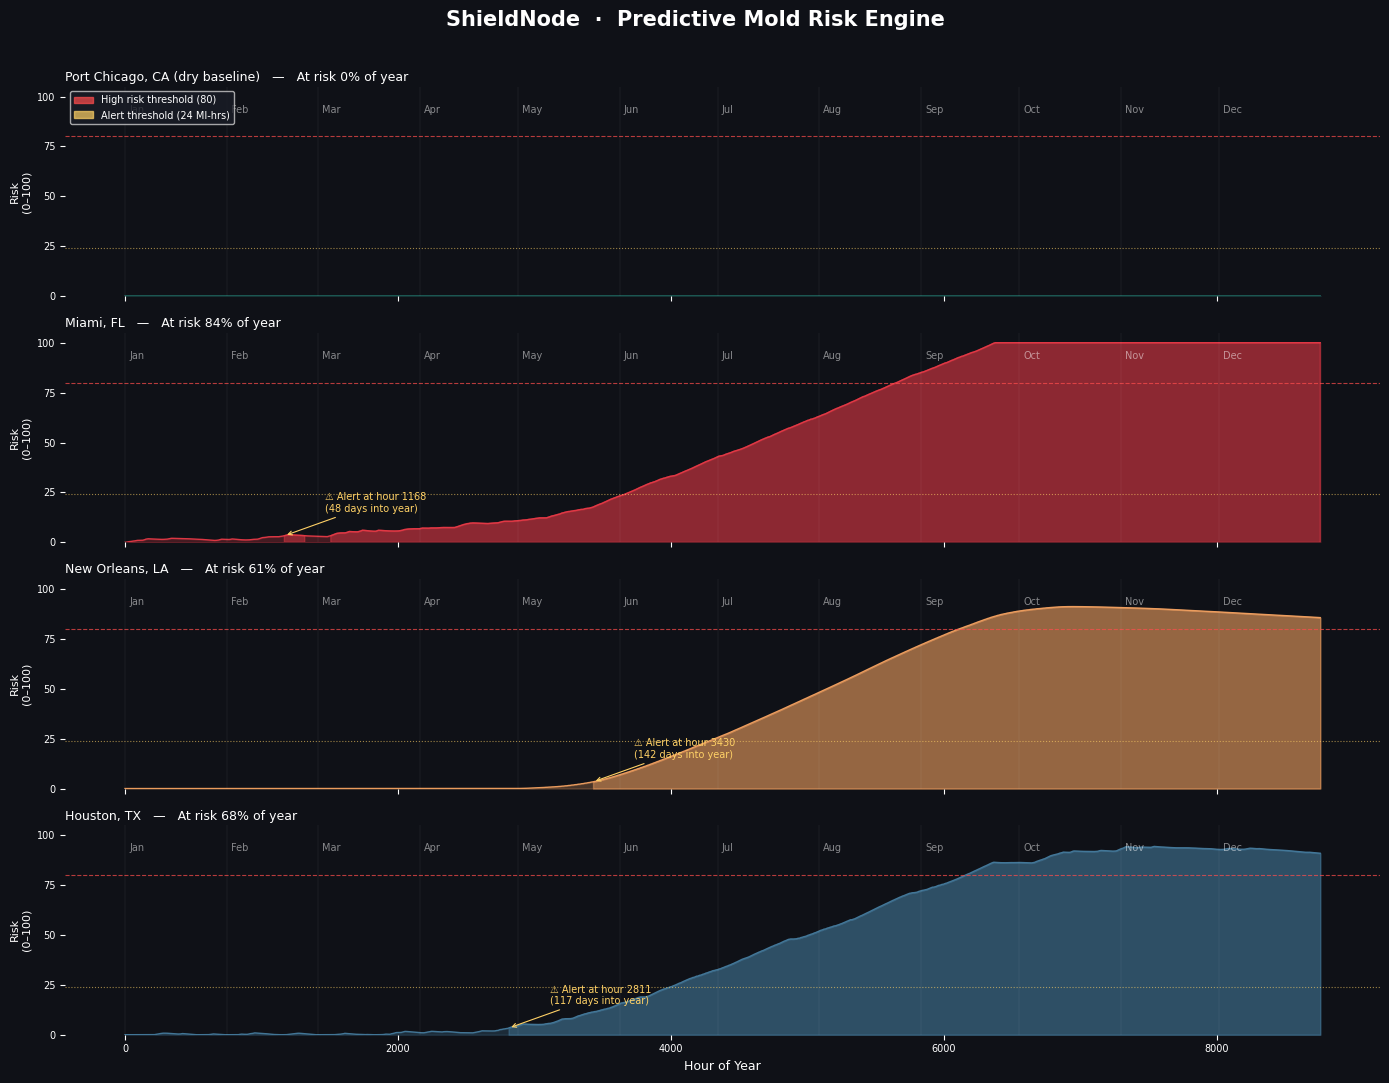

Saved: 04_hero_chart.png


In [3]:
# This is the single chart you show judges first.
# One panel per city, risk score over the year,
# with a "days to alert" annotation on the first crossing.

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
fig.patch.set_facecolor('#0f1117')
for ax in axes:
    ax.set_facecolor('#0f1117')

fig.suptitle("ShieldNode  ·  Predictive Mold Risk Engine",
             fontsize=15, fontweight='bold',
             color='white', y=0.98)

for ax, (name, df) in zip(axes, epw_dfs.items()):
    res   = simulate_wall_cavity(df, insulation_r=13)
    hours = np.arange(8760)
    score = res['risk_score']
    alert = res['alert']
    color = CITY_COLORS.get(name, 'white')
    label = CITY_LABELS.get(name, name)

    # Background gradient fill
    ax.fill_between(hours, score, alpha=0.25, color=color)
    ax.fill_between(hours, score, where=alert,
                    alpha=0.45, color=color)
    ax.plot(hours, score, linewidth=1.0,
            color=color, alpha=0.95)

    # Threshold lines
    ax.axhline(80, color='#ff4d4d', linestyle='--',
               linewidth=0.8, alpha=0.7)
    ax.axhline(24, color='#ffd166', linestyle=':',
               linewidth=0.8, alpha=0.6)

    # Month dividers
    for ms in MONTH_STARTS:
        ax.axvline(ms, color='white', linewidth=0.2, alpha=0.2)
    for ms, mn in zip(MONTH_STARTS, MONTH_NAMES):
        ax.text(ms + 30, 92, mn, fontsize=7,
                color='white', alpha=0.5)

    # First alert annotation
    if alert.any():
        first = int(np.argmax(alert))
        ax.annotate(
            f"⚠ Alert at hour {first}\n({first//24} days into year)",
            xy=(first, score[first]),
            xytext=(first + 300, score[first] + 12),
            fontsize=7, color='#ffd166',
            arrowprops=dict(arrowstyle='->', color='#ffd166',
                            lw=0.8),
        )

    pct = alert.mean() * 100
    ax.set_title(
        f"{label}   —   At risk {pct:.0f}% of year",
        fontsize=9, color='white', loc='left', pad=4
    )
    ax.set_ylabel("Risk\n(0–100)", fontsize=8, color='white')
    ax.set_ylim(0, 105)
    ax.tick_params(colors='white', labelsize=7)
    ax.spines[:].set_visible(False)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(25))

axes[-1].set_xlabel("Hour of Year", fontsize=9, color='white')

# Legend
legend_elements = [
    mpatches.Patch(color='#ff4d4d', alpha=0.7,
                   label='High risk threshold (80)'),
    mpatches.Patch(color='#ffd166', alpha=0.7,
                   label='Alert threshold (24 MI-hrs)'),
]
axes[0].legend(handles=legend_elements, fontsize=7,
               facecolor='#1a1d27', labelcolor='white',
               loc='upper left', framealpha=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG_DIR / "04_hero_chart.png", dpi=180,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Saved: 04_hero_chart.png")

In [4]:
# For each city and month of onset, compute how many days
# ShieldNode would fire an alert BEFORE the MI hits 100
# (i.e. before mold is visible/established)

def days_to_alert(res, alert_threshold=24, max_threshold=500):
    """
    For each alert event, compute how many hours elapsed
    between first exceeding alert_threshold and hitting max_threshold.
    This is the early warning window ShieldNode provides.
    """
    mi    = res['mi']
    alert = res['alert']
    if not alert.any():
        return None

    first_alert = int(np.argmax(alert))

    # Find when MI first hits max_threshold after alert
    post_alert = mi[first_alert:]
    if post_alert.max() < max_threshold:
        warning_hours = len(post_alert)  # never hit max in dataset
    else:
        warning_hours = int(np.argmax(post_alert >= max_threshold))

    return {
        'first_alert_hour':  first_alert,
        'first_alert_day':   first_alert // 24,
        'warning_hours':     warning_hours,
        'warning_days':      warning_hours // 24,
        'first_alert_month': next(
            (m for m, s in zip(MONTH_NAMES, MONTH_STARTS)
             if s > first_alert), 'Dec'
        ),
    }

print("Early Warning Analysis — ShieldNode vs Visible Mold")
print("=" * 60)
print(f"{'City':<28} {'Alert fires':<15} {'Warning window'}")
print("-" * 60)

warning_data = {}
for name, df in epw_dfs.items():
    label = CITY_LABELS.get(name, name)
    res   = simulate_wall_cavity(df, insulation_r=13)
    info  = days_to_alert(res)
    warning_data[label] = info
    if info:
        print(f"{label:<28} Day {info['first_alert_day']:<10} "
              f"{info['warning_days']} days before established growth")
    else:
        print(f"{label:<28} No alert triggered")

Early Warning Analysis — ShieldNode vs Visible Mold
City                         Alert fires     Warning window
------------------------------------------------------------
Port Chicago, CA (dry baseline) No alert triggered
Miami, FL                    Day 48         172 days before established growth
New Orleans, LA              Day 142        96 days before established growth
Houston, TX                  Day 117        120 days before established growth


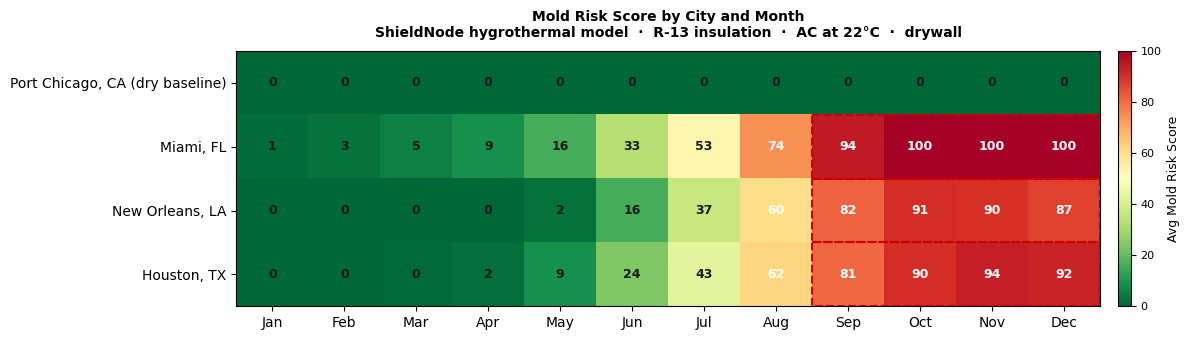

Saved: 04_pitch_heatmap.png


In [5]:
# Clean, minimal heatmap designed to be dropped directly
# into a pitch deck slide

month_hours = [744,672,744,720,744,720,
               744,744,720,744,720,744]

monthly_data = {}
for name, df in epw_dfs.items():
    res    = simulate_wall_cavity(df, insulation_r=13)
    scores = res['risk_score']
    monthly = []
    idx = 0
    for hrs in month_hours:
        monthly.append(scores[idx:idx+hrs].mean())
        idx += hrs
    monthly_data[CITY_LABELS.get(name, name)] = monthly

monthly_df = pd.DataFrame(monthly_data, index=MONTH_NAMES).T

fig, ax = plt.subplots(figsize=(12, 3.5))
fig.patch.set_facecolor('white')

im = ax.imshow(monthly_df.values, cmap='RdYlGn_r',
               vmin=0, vmax=100, aspect='auto')

cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Avg Mold Risk Score', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_NAMES, fontsize=10)
ax.set_yticks(range(len(monthly_df)))
ax.set_yticklabels(monthly_df.index, fontsize=10)
ax.set_title(
    "Mold Risk Score by City and Month\n"
    "ShieldNode hygrothermal model  ·  "
    "R-13 insulation  ·  AC at 22°C  ·  drywall",
    fontsize=10, fontweight='bold', pad=10
)

for i in range(len(monthly_df)):
    for j in range(12):
        val = monthly_df.values[i, j]
        ax.text(j, i, f"{val:.0f}",
                ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if val > 55 else '#1a1a1a')

# Box around the high-risk zone
for i, row in enumerate(monthly_df.values):
    first_high = next((j for j, v in enumerate(row) if v >= 80), None)
    if first_high is not None:
        rect = plt.Rectangle(
            (first_high - 0.5, i - 0.5),
            12 - first_high, 1,
            linewidth=1.5, edgecolor='#cc0000',
            facecolor='none', linestyle='--'
        )
        ax.add_patch(rect)

plt.tight_layout()
plt.savefig(FIG_DIR / "04_pitch_heatmap.png", dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 04_pitch_heatmap.png")

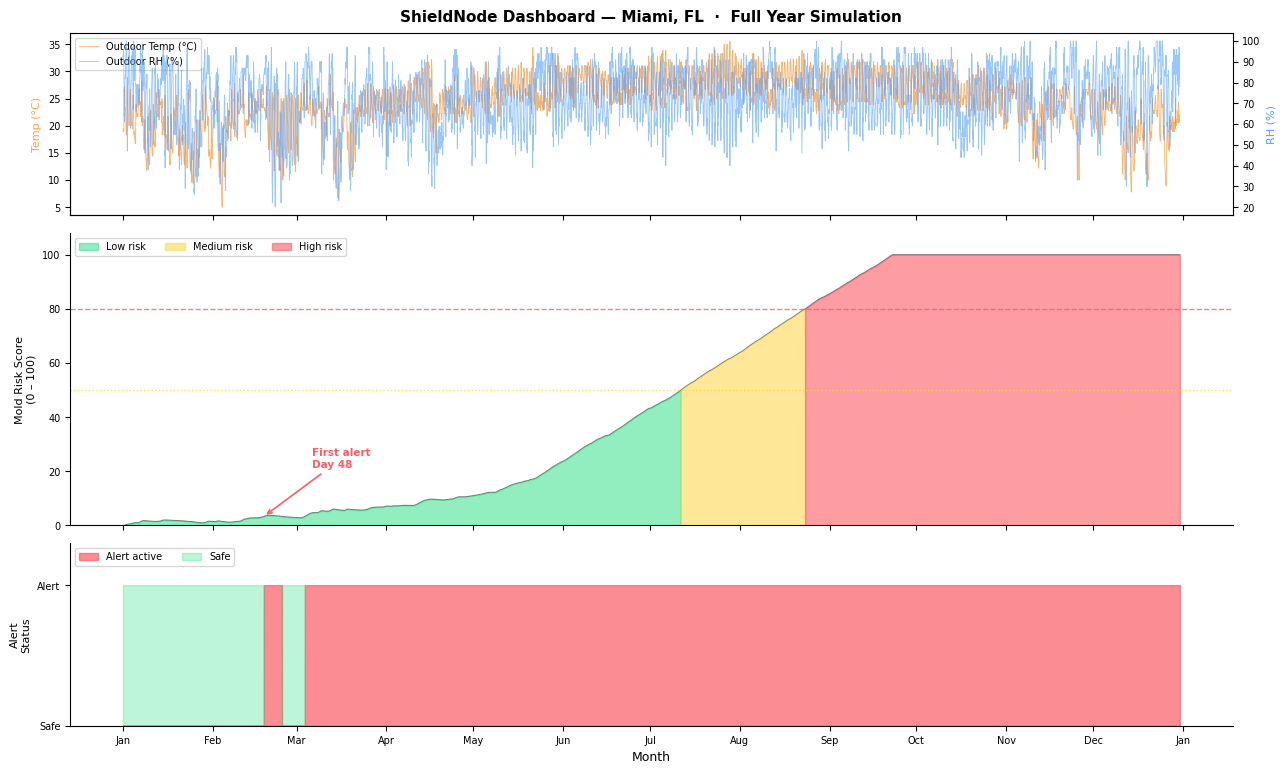

Saved: 04_dashboard_demo.png


In [6]:
# This is the "live demo" chart — what a property manager
# would actually see in the ShieldNode dashboard.
# Shows one building in Miami, one full year,
# with alert events annotated.

df    = epw_dfs['USA_FL_Miami.Intl.AP']
res   = simulate_wall_cavity(df, insulation_r=13)
hours = np.arange(8760)

# Build a time index for readable x-axis
time_idx = pd.date_range('2024-01-01', periods=8760, freq='h')

fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(3, 1, height_ratios=[1, 1.6, 1],
                        hspace=0.08)

# Panel 1: outdoor conditions
ax1 = fig.add_subplot(gs[0])
ax1b = ax1.twinx()
ax1.plot(time_idx, df['dry_bulb_temp'].values,
         color='#ff9f43', linewidth=0.6, alpha=0.8,
         label='Outdoor Temp (°C)')
ax1b.plot(time_idx, df['rel_humidity'].values,
          color='#54a0ff', linewidth=0.6, alpha=0.6,
          label='Outdoor RH (%)')
ax1.set_ylabel("Temp (°C)", fontsize=8, color='#ff9f43')
ax1b.set_ylabel("RH (%)", fontsize=8, color='#54a0ff')
ax1.set_title("ShieldNode Dashboard — Miami, FL  ·  Full Year Simulation",
              fontsize=11, fontweight='bold', pad=8)
ax1.tick_params(labelbottom=False, labelsize=7)
ax1b.tick_params(labelsize=7)
ax1.spines[['top','right']].set_visible(False)
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, fontsize=7,
           loc='upper left')

# Panel 2: risk score with alert zones
ax2 = fig.add_subplot(gs[1], sharex=ax1)
score = res['risk_score']
alert = res['alert']

# Color the risk score by severity
ax2.fill_between(time_idx, score,
                 where=(score < 50),
                 alpha=0.5, color='#26de81', label='Low risk')
ax2.fill_between(time_idx, score,
                 where=((score >= 50) & (score < 80)),
                 alpha=0.5, color='#fed330', label='Medium risk')
ax2.fill_between(time_idx, score,
                 where=(score >= 80),
                 alpha=0.6, color='#fc5c65', label='High risk')
ax2.plot(time_idx, score, linewidth=0.7,
         color='#2f3542', alpha=0.6)
ax2.axhline(80, color='#fc5c65', linestyle='--',
            linewidth=1, alpha=0.8)
ax2.axhline(50, color='#fed330', linestyle=':',
            linewidth=1, alpha=0.8)
ax2.set_ylabel("Mold Risk Score\n(0 – 100)", fontsize=8)
ax2.set_ylim(0, 108)
ax2.tick_params(labelbottom=False, labelsize=7)
ax2.spines[['top','right']].set_visible(False)
ax2.legend(fontsize=7, loc='upper left', ncol=3)

# Annotate first alert
if alert.any():
    first_idx = int(np.argmax(alert))
    ax2.annotate(
        f"First alert\nDay {first_idx//24}",
        xy=(time_idx[first_idx], score[first_idx]),
        xytext=(time_idx[first_idx + 400],
                score[first_idx] + 18),
        fontsize=7.5, color='#fc5c65', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#fc5c65',
                        lw=1.2),
    )

# Panel 3: alert status bar
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.fill_between(time_idx, alert.astype(int),
                 alpha=0.7, color='#fc5c65',
                 label='Alert active')
ax3.fill_between(time_idx, (~alert).astype(int),
                 alpha=0.3, color='#26de81',
                 label='Safe')
ax3.set_ylabel("Alert\nStatus", fontsize=8)
ax3.set_ylim(0, 1.3)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Safe', 'Alert'], fontsize=7)
ax3.set_xlabel("Month", fontsize=9)
ax3.tick_params(labelsize=7)
ax3.spines[['top','right']].set_visible(False)
ax3.legend(fontsize=7, loc='upper left', ncol=2)

# Format x axis
import matplotlib.dates as mdates
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.savefig(FIG_DIR / "04_dashboard_demo.png", dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 04_dashboard_demo.png")

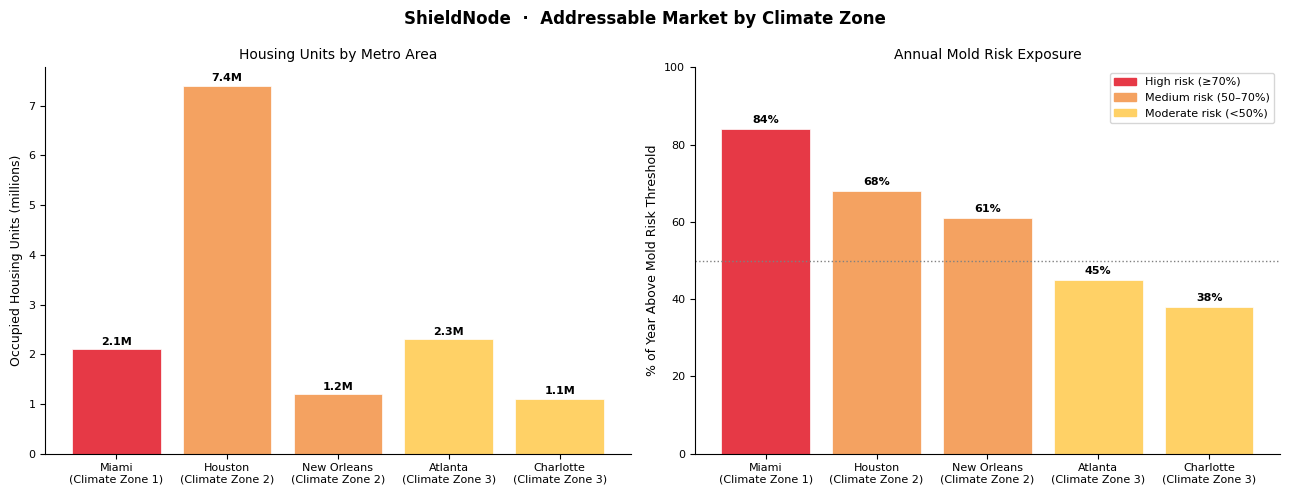

Saved: 04_market_visual.png


In [7]:
# A simple bar chart showing the addressable market
# by climate zone — for the business slide

climate_data = {
    'Miami\n(Climate Zone 1)':      {'homes_M': 2.1,  'pct_risk': 84},
    'Houston\n(Climate Zone 2)':    {'homes_M': 7.4,  'pct_risk': 68},
    'New Orleans\n(Climate Zone 2)':{'homes_M': 1.2,  'pct_risk': 61},
    'Atlanta\n(Climate Zone 3)':    {'homes_M': 2.3,  'pct_risk': 45},
    'Charlotte\n(Climate Zone 3)':  {'homes_M': 1.1,  'pct_risk': 38},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ShieldNode  ·  Addressable Market by Climate Zone",
             fontsize=12, fontweight='bold')

cities   = list(climate_data.keys())
homes    = [v['homes_M'] for v in climate_data.values()]
risk_pct = [v['pct_risk'] for v in climate_data.values()]

colors_bar = ['#e63946' if r >= 70
              else '#f4a261' if r >= 50
              else '#ffd166'
              for r in risk_pct]

# Bar 1: homes at risk
bars = ax1.bar(cities, homes, color=colors_bar,
               edgecolor='white', linewidth=0.5)
ax1.set_ylabel("Occupied Housing Units (millions)", fontsize=9)
ax1.set_title("Housing Units by Metro Area", fontsize=10)
ax1.tick_params(labelsize=8)
ax1.spines[['top','right']].set_visible(False)
for bar, h in zip(bars, homes):
    ax1.text(bar.get_x() + bar.get_width()/2,
             h + 0.05, f"{h}M",
             ha='center', va='bottom', fontsize=8,
             fontweight='bold')

# Bar 2: % of year at risk
bars2 = ax2.bar(cities, risk_pct, color=colors_bar,
                edgecolor='white', linewidth=0.5)
ax2.set_ylabel("% of Year Above Mold Risk Threshold", fontsize=9)
ax2.set_title("Annual Mold Risk Exposure", fontsize=10)
ax2.axhline(50, color='gray', linestyle=':', linewidth=1)
ax2.tick_params(labelsize=8)
ax2.spines[['top','right']].set_visible(False)
ax2.set_ylim(0, 100)
for bar, r in zip(bars2, risk_pct):
    ax2.text(bar.get_x() + bar.get_width()/2,
             r + 1, f"{r}%",
             ha='center', va='bottom', fontsize=8,
             fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#e63946', label='High risk (≥70%)'),
    mpatches.Patch(color='#f4a261', label='Medium risk (50–70%)'),
    mpatches.Patch(color='#ffd166', label='Moderate risk (<50%)'),
]
ax2.legend(handles=legend_patches, fontsize=8,
           loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / "04_market_visual.png", dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 04_market_visual.png")

In [8]:
print("=" * 58)
print("  NOTEBOOK 4 COMPLETE — PITCH ASSETS GENERATED")
print("=" * 58)

figures = [
    ("04_hero_chart.png",     "Annual risk — all 4 cities, dark theme"),
    ("04_pitch_heatmap.png",  "Monthly risk heatmap — pitch slide"),
    ("04_dashboard_demo.png", "Full dashboard demo — Miami"),
    ("04_market_visual.png",  "Market size by climate zone"),
    ("02_algorithm_validation.png", "Algorithm validation (nb2)"),
    ("03_epw_risk_timeseries.png",  "EPW time series (nb3)"),
    ("03_monthly_risk_heatmap.png", "Monthly heatmap (nb3)"),
]

print("\n  Figures ready for pitch deck:")
for fname, desc in figures:
    path = FIG_DIR / fname
    exists = "✓" if path.exists() else "✗ missing"
    print(f"  {exists}  {fname:<35} {desc}")

print()
print("  PITCH DECK ORDER:")
print("  Slide 1  — Problem (73K amputations / mold stats)")
print("  Slide 2  — 04_hero_chart.png")
print("  Slide 3  — 04_pitch_heatmap.png")
print("  Slide 4  — 04_dashboard_demo.png")
print("  Slide 5  — Market (04_market_visual.png)")
print("  Slide 6  — Hardware BOM + sensor spec")
print("  Slide 7  — Business model (HaaS + SaaS)")
print("  Slide 8  — Ask + roadmap")
print("=" * 58)

  NOTEBOOK 4 COMPLETE — PITCH ASSETS GENERATED

  Figures ready for pitch deck:
  ✓  04_hero_chart.png                   Annual risk — all 4 cities, dark theme
  ✓  04_pitch_heatmap.png                Monthly risk heatmap — pitch slide
  ✓  04_dashboard_demo.png               Full dashboard demo — Miami
  ✓  04_market_visual.png                Market size by climate zone
  ✗ missing  02_algorithm_validation.png         Algorithm validation (nb2)
  ✓  03_epw_risk_timeseries.png          EPW time series (nb3)
  ✓  03_monthly_risk_heatmap.png         Monthly heatmap (nb3)

  PITCH DECK ORDER:
  Slide 1  — Problem (73K amputations / mold stats)
  Slide 2  — 04_hero_chart.png
  Slide 3  — 04_pitch_heatmap.png
  Slide 4  — 04_dashboard_demo.png
  Slide 5  — Market (04_market_visual.png)
  Slide 6  — Hardware BOM + sensor spec
  Slide 7  — Business model (HaaS + SaaS)
  Slide 8  — Ask + roadmap
